# Lab 6 — The Executive Delivery Clinic
### SDA-DSC-112 · Module 6 · Executive Communication and Presentation Lab · **50 minutes**

| | |
|---|---|
| **Objective** | Deliver the Module 5 seven-slide narrative to a simulated Steering Committee in a 7-minute slot, handle a Q&A round, and improve measurably across two recorded rehearsal rounds |
| **Dataset** | `story/tayseer_storyboard.py` (from Lab 5) · `qa_bank.csv` · `rehearsal_scores.csv` · `investment_option_region_allocation.csv` |
| **Output** | `story/speaker_notes.py` · `story/qa_prep.py` · `story/rehearsal_score.py` · the round-1 → round-2 delta, charted |

| Task | Minutes |
|---|---|
| 1 · Timed speaker notes, and the halved-slot cut | 5 |
| 2 · The Q&A preparation matrix | 5 |
| 3 · Round 1 — deliver, recorded | 10 |
| 4 · Self-review against the rubric | 5 |
| 5 · Structured peer critique | 5 |
| 6 · Round 2 — re-deliver with the fixes | 10 |
| 7 · Score round 2, compute the delta, name the biggest mover | 5 |

> **This lab depends on Lab 5.** Run `lab5_storyboard_solution.ipynb` first — the
> speaker-notes generator imports `story/tayseer_storyboard.py` from it.
>
> **Recording is the engine of this lab.** Obtain consent up front and make clear the
> videos belong to the participants. The Round-1 → Round-2 delta is the learning signal,
> not the Round-1 score.

### Setup

In [1]:
import sys, pathlib, importlib

sys.path.insert(0, str(pathlib.Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tayseer_viz as tv
tv.apply_theme()

STORY_DIR = pathlib.Path.cwd() / "story"
assert (STORY_DIR / "tayseer_storyboard.py").exists(), (
    "Run lab5_storyboard_solution.ipynb first — this lab imports its storyboard.")

import story.tayseer_storyboard as sb
importlib.reload(sb)

qa_bank = tv.load("qa_bank.csv")
rehearsal = tv.load("rehearsal_scores.csv")
alloc = tv.load("investment_option_region_allocation.csv")
roster = tv.load("participants_roster.csv")

print(f"storyboard: {len(sb.STORYBOARD)} scenes · qa_bank: {len(qa_bank)} questions · "
      f"rehearsal: {len(rehearsal)} rubric rows · cohort: {len(roster)}")

storyboard: 7 scenes · qa_bank: 12 questions · rehearsal: 288 rubric rows · cohort: 24


---
## Task 1 — Timed speaker notes, and the halved-slot cut *(5 min)*

The spoken briefing has its own structure, layered on the seven-slide arc:

| Time | Beat |
|---|---|
| 0:00–0:30 | **The top-line.** "I'm recommending we direct the next SAR 40 million to five stalled regions to hit 65% by December. Here's why in three points." |
| 0:30–5:00 | Three supporting beats — situation, complication, evidence — one chart, one message each |
| 5:00–6:30 | Options and the recommendation |
| 6:30–7:00 | The ask and the next step |

**Say the ask twice** — once at the top (BLUF) and once at the close. Everything between
earns the second ask.

In [2]:
SPEAKER_NOTES_SRC = r'''
"""story/speaker_notes.py — timed speaker notes generated from the Module 5 storyboard.

Delivery is a plan too. Every scene gets a time box and a one-line narration cue, and
the ask is stated twice: once at 0:00 (BLUF) and once at the close.

The generator also produces the HALVED-SLOT version, because a committee chair cutting
your seven minutes to three on the spot is a normal event, not an emergency.
"""
from __future__ import annotations

from story.tayseer_storyboard import BIG_IDEA, STORYBOARD

# seconds per arc role; the sum must fit the slot with headroom for Q&A hand-off
TIME_BOX = {
    "BLUF": 30,
    "situation": 45,
    "complication": 60,
    "evidence": 75,
    "options": 90,
    "resolution": 60,
    "ask": 30,
}

SLOT_SECONDS = 7 * 60
THE_ASK = "Approve the reallocation of SAR 40M to OPT-A; first checkpoint in 90 days."


def build_notes(storyboard=STORYBOARD, time_box=None, slot=SLOT_SECONDS,
                echo: bool = True) -> list[dict]:
    """Return timed notes, one entry per scene. Raises if the plan overruns the slot."""
    time_box = time_box or TIME_BOX
    total = 0
    notes = []
    if echo:
        print(f"OPEN 0:00 — say the ask: {THE_ASK}")
        print(f"          (the Big Idea behind it: {BIG_IDEA})\n")
    for s in storyboard:
        secs = time_box.get(s.arc_role, 45)
        start = total
        total += secs
        note = {
            "n": s.n,
            "arc_role": s.arc_role,
            "starts_at": f"{start // 60}:{start % 60:02d}",
            "ends_at": f"{total // 60}:{total % 60:02d}",
            "seconds": secs,
            "orient": "One line on what the axes are, then the takeaway.",
            "assert": s.message,
            "point_at": "the highlighted mark only — do NOT read the chart",
            "evidence_if_challenged": s.evidence,
        }
        notes.append(note)
        if echo:
            print(f"[{note['starts_at']}–{note['ends_at']}] Slide {s.n} "
                  f"({s.arc_role}, {secs}s)")
            print(f"   Orient : {note['orient']}")
            print(f"   Assert : \"{s.message}\"")
            print(f"   Point  : {note['point_at']}")
            print(f"   If challenged: {s.evidence[:96]}...\n")
    assert total <= slot, f"Over slot by {total - slot}s — cut a scene, do not rush."
    if echo:
        print(f"CLOSE — say the ask AGAIN: {THE_ASK}")
        print(f"Total: {total // 60}:{total % 60:02d} / {slot // 60}:{slot % 60:02d}  "
              f"({slot - total}s headroom for the hand-off)")
    return notes


def halved_slot(storyboard=STORYBOARD, keep=("BLUF", "complication", "ask"),
                echo: bool = True) -> list[dict]:
    """The chair just halved your slot. What survives: the ask, the single strongest
    evidence scene, the ask again."""
    cut = [s for s in storyboard if s.arc_role in keep]
    if echo:
        print("HALVED SLOT (3:00) — what survives:")
    return build_notes(cut, slot=3 * 60, echo=echo)
'''

notes_path = STORY_DIR / "speaker_notes.py"
notes_path.write_text(SPEAKER_NOTES_SRC, encoding="utf-8")
compile(SPEAKER_NOTES_SRC, str(notes_path), "exec")
print("wrote", notes_path, "\n")

import story.speaker_notes as sn
importlib.reload(sn)

notes = sn.build_notes()
plan = pd.DataFrame(notes)[["n", "arc_role", "starts_at", "ends_at", "seconds", "assert"]]
display(plan)

total = plan.seconds.sum()
assert total <= sn.SLOT_SECONDS, f"over slot by {total - sn.SLOT_SECONDS}s"
print(f"\nTotal {total//60}:{total%60:02d} / 7:00 — "
      f"{sn.SLOT_SECONDS - total}s of headroom for the Q&A hand-off.")
print("Ask stated at 0:00 (BLUF) and again at the close: "
      f"{notes[0]['arc_role'] == 'BLUF' and notes[-1]['arc_role'] == 'ask'}")

print("\n" + "=" * 72)
short = sn.halved_slot()

wrote /home/claude/work/pkg/notebooks/story/speaker_notes.py 

OPEN 0:00 — say the ask: Approve the reallocation of SAR 40M to OPT-A; first checkpoint in 90 days.
          (the Big Idea behind it: Five stalled regions hold national digital adoption 1.2 points below the 65% target; directing the next SAR 40 million to targeted regional activation there - rather than to the channel rebuild - is the only option that closes the gap by December.)

[0:00–0:30] Slide 1 (BLUF, 30s)
   Orient : One line on what the axes are, then the takeaway.
   Assert : "Direct the next SAR 40M to the five stalled regions to reach 65% by December"
   Point  : the highlighted mark only — do NOT read the chart
   If challenged: OPT-A lifts 4 of 5 stalled regions past 65%; OPT-B and OPT-C lift none....

[0:30–1:15] Slide 2 (situation, 45s)
   Orient : One line on what the axes are, then the takeaway.
   Assert : "Digital adoption nearly doubled in five years, to 63.8% against a 65% target"
   Point  : the highl

,n,arc_role,starts_at,ends_at,seconds,assert
0,1,BLUF,0:00,0:30,30,Direct the next SAR 40M to the five stalled re...
1,2,situation,0:30,1:15,45,"Digital adoption nearly doubled in five years,..."
2,3,complication,1:15,2:15,60,"Nine regions sit below target, and five of the..."
3,4,evidence,2:15,3:30,75,"They are not small, and the cause is specific:..."
4,5,options,3:30,5:00,90,"Three uses of SAR 40M, compared on gap closed ..."
5,6,resolution,5:00,6:00,60,Only targeted regional activation lifts the st...
6,7,ask,6:00,6:30,30,"Approve the reallocation to OPT-A, with a firs..."



Total 6:30 / 7:00 — 30s of headroom for the Q&A hand-off.
Ask stated at 0:00 (BLUF) and again at the close: True

HALVED SLOT (3:00) — what survives:
OPEN 0:00 — say the ask: Approve the reallocation of SAR 40M to OPT-A; first checkpoint in 90 days.
          (the Big Idea behind it: Five stalled regions hold national digital adoption 1.2 points below the 65% target; directing the next SAR 40 million to targeted regional activation there - rather than to the channel rebuild - is the only option that closes the gap by December.)

[0:00–0:30] Slide 1 (BLUF, 30s)
   Orient : One line on what the axes are, then the takeaway.
   Assert : "Direct the next SAR 40M to the five stalled regions to reach 65% by December"
   Point  : the highlighted mark only — do NOT read the chart
   If challenged: OPT-A lifts 4 of 5 stalled regions past 65%; OPT-B and OPT-C lift none....

[0:30–1:30] Slide 3 (complication, 60s)
   Orient : One line on what the axes are, then the takeaway.
   Assert : "Nine reg

**Instructor commentary.** Two things to draw out. First, the plan comes in at 6:30, not
7:00 — the thirty seconds of headroom are deliberate, because a briefing that fills its
slot exactly overruns the moment anyone interrupts. Second, `halved_slot()` is not a
gimmick: a chair cutting your time on the spot is a normal event, and a presenter who has
*rehearsed* the cut keeps the ask and the strongest evidence while everyone else panics
and reads faster. Rehearse the cut with the room.

Note what the notes tell the presenter to do with each chart: **orient, then assert,
then point at one mark.** Never read the chart — the title already states the takeaway,
and the presenter's job is the *why* and the *so what*.

---
## Task 2 — The Q&A preparation matrix *(5 min)*

At least four questions, including **one hostile** and **one "your data is wrong"**, each
with an answer and a **bridge back to the Big Idea**.

`qa_bank.csv` ships twelve real committee questions with model answers, bridges and
appendix references. Build the matrix from the bank; do not invent questions at the desk.

Two master rules: **bridge back after every answer**, and **never bluff a number**.

In [3]:
QA_PREP_SRC = r'''
"""story/qa_prep.py — the Q&A preparation matrix.

Every answer has the same three beats: ACKNOWLEDGE, answer BRIEFLY, then BRIDGE back
to the Big Idea. Two master rules: bridge after every answer, and never bluff a number.

The bank ships as data (`qa_bank.csv`, 12 committee questions), so the matrix is built
from the real bank rather than invented at the desk.
"""
from __future__ import annotations

import pandas as pd

TECHNIQUE = {
    "Clarifying": "Answer briefly, return to the arc.",
    "Hostile": "Separate the number from the recommendation; acknowledge, route to "
               "appendix, hold the thread.",
    "Data is wrong": "Concede the figure if it is arguable, show the recommendation "
                     "survives the lower estimate, reconcile in the appendix.",
    "Off-topic": "Acknowledge, park it, redirect to the decision on the table.",
    "Unknown": "Say you do not have it, commit to a date. Never bluff a number.",
}

REQUIRED_TYPES = {"Hostile", "Data is wrong"}


def build_matrix(qa_bank: pd.DataFrame, min_rows: int = 4,
                 likelihood: tuple[str, ...] = ("High", "Medium")) -> pd.DataFrame:
    """Select the questions worth rehearsing and attach the technique to each."""
    m = qa_bank[qa_bank.likelihood.isin(likelihood)].copy()
    m["technique"] = m.question_type.map(TECHNIQUE).fillna(TECHNIQUE["Clarifying"])
    m = m[["qa_id", "question_type", "technique", "question", "model_answer",
           "bridge_back_to_big_idea", "appendix_reference", "likelihood"]]
    assert len(m) >= min_rows, f"rehearse at least {min_rows} questions"
    missing = REQUIRED_TYPES - set(m.question_type)
    assert not missing, f"the matrix must include: {missing}"
    return m.reset_index(drop=True)


def drill(matrix: pd.DataFrame, n: int | None = None) -> None:
    """Print the matrix as a rehearsal drill: acknowledge -> answer -> bridge."""
    rows = matrix if n is None else matrix.head(n)
    for i, item in enumerate(rows.itertuples(), 1):
        print(f"Q{i} [{item.question_type}] {item.question}")
        print(f"   technique : {item.technique}")
        print(f"   answer    : {item.model_answer}")
        print(f"   ->bridge  : ...{item.bridge_back_to_big_idea}")
        print(f"   appendix  : {item.appendix_reference}\n")


def unprepared_bridge(question: str, big_idea_clause: str) -> str:
    """Round 2 asks an UNPREPARED question. The shape of the answer is still fixed."""
    return (f"Acknowledge: \"That is a fair question.\"  "
            f"Answer briefly and honestly — if you do not know, say so and commit to a "
            f"date.  Bridge: \"...which is exactly why {big_idea_clause}\"")
'''

qa_path = STORY_DIR / "qa_prep.py"
qa_path.write_text(QA_PREP_SRC, encoding="utf-8")
compile(QA_PREP_SRC, str(qa_path), "exec")
print("wrote", qa_path, "\n")

import story.qa_prep as qp
importlib.reload(qp)

matrix = qp.build_matrix(qa_bank)
pd.set_option("display.max_colwidth", 60)
display(matrix[["qa_id", "question_type", "question", "bridge_back_to_big_idea",
                "appendix_reference", "likelihood"]])
print(f"\n{len(matrix)} questions rehearsed, covering "
      f"{matrix.question_type.nunique()} question types "
      f"({', '.join(sorted(matrix.question_type.unique()))}).\n")

qp.drill(matrix, n=4)

print("=" * 72)
print("Round 2 will ask an UNPREPARED question. The shape of the answer is still fixed:")
print(qp.unprepared_bridge(
    "How does this interact with the Absher roadmap?",
    "targeted regional activation is the fastest route to 65% by December"))

wrote /home/claude/work/pkg/notebooks/story/qa_prep.py 



,qa_id,question_type,question,bridge_back_to_big_idea,appendix_reference,likelihood
0,QA-01,Hostile,Aren't those regions just small? Why spend 40 million th...,"so targeted spend closes the real gap, not a rounding er...",A2 - per-capita evidence,High
1,QA-02,Data is wrong,Adoption looks higher than the finance report.,and the recommendation holds at finance's lower figure too.,A5 - measure definitions,High
2,QA-03,Off-topic,Why not spend it on the app instead?,so region targeting is the only option that reaches 65% ...,A3 - options comparison,Medium
3,QA-04,Clarifying,What happens if we do nothing?,which is why the ask is a targeted intervention now.,A4 - do-nothing projection,High
4,QA-05,Hostile,Your cost saving assumes every shifted transaction is free.,and even at half that gap the payback is under nine months.,A6 - saving sensitivity,Medium
5,QA-06,Data is wrong,Jazan's completion time looks impossible.,which is exactly the workload the intervention removes.,A7 - completion distribution,Medium
6,QA-08,Off-topic,Can we split the budget across all three options?,so the fastest path to 65% is to fund Option A whole.,A3 - options comparison,Medium
7,QA-09,Hostile,Satisfaction fell in Tabuk while adoption rose. Isn't di...,"which is a scoped fix inside Option A, not an argument a...",A9 - Tabuk detail,High
8,QA-10,Clarifying,When would we see the first evidence it is working?,and I propose a 90-day checkpoint against that slope.,A10 - measurement plan,High
9,QA-11,Data is wrong,The national figure moved between two of your slides.,and the gap between them is the whole argument.,A5 - measure definitions,Medium



10 questions rehearsed, covering 4 question types (Clarifying, Data is wrong, Hostile, Off-topic).

Q1 [Hostile] Aren't those regions just small? Why spend 40 million there?
   technique : Separate the number from the recommendation; acknowledge, route to appendix, hold the thread.
   answer    : They hold 15.8% of the population, run 12.1% below the national digital-transactions-per-capita figure, and carry the highest unit cost in the country (24.6 vs 14.6 SAR).
   ->bridge  : ...so targeted spend closes the real gap, not a rounding error.
   appendix  : A2 - per-capita evidence

Q2 [Data is wrong] Adoption looks higher than the finance report.
   technique : Concede the figure if it is arguable, show the recommendation survives the lower estimate, reconcile in the appendix.
   answer    : Finance averages the regional column; we recompute from unique_users, which is the non-additive-safe method.
   ->bridge  : ...and the recommendation holds at finance's lower figure too.
   append

**Instructor commentary.** Read QA-02's model answer aloud and let it land: *"Finance
averages the regional column; we recompute from unique_users, which is the
non-additive-safe method"* — followed by *"and the recommendation holds at Finance's lower
figure too."* That is Modules 4 and 6 meeting in one sentence. The technical correctness
wins the point; the bridge is what stops the point from becoming a ten-minute argument.

Run the bridge drill with the room: fire hostile and off-topic questions rapid-fire, and
require *acknowledge → brief answer → bridge* in a single breath each. The physical
constraint of one breath is what stops people over-explaining.

---
## Task 3 — Round 1: deliver, recorded *(10 min)*

Deliver the 7-minute briefing to your pair, who play the committee and ask **two**
questions from your matrix. Record it.

In the notebook we work with the cohort's actual recorded rounds
(`rehearsal_scores.csv`: 24 participants × 2 rounds × 6 weighted criteria) so the scoring
machinery is real, and so the instructor has the benchmark before the room does.

In [4]:
REHEARSAL_SRC = r'''
"""story/rehearsal_score.py — the fixed critique rubric, applied to two recorded rounds.

Score delivery the SAME way each round so the DELTA is the learning signal. The rubric
is weighted (see `rehearsal_scores.csv`), so a round total is the weighted percentage of
the maximum, not a raw average.
"""
from __future__ import annotations

import pandas as pd

CRITERIA = {
    "Opening / BLUF": 0.20,
    "One message per slide": 0.15,
    "Chart delivery": 0.20,
    "Q&A handling": 0.20,
    "Time discipline": 0.15,
    "Presence": 0.10,
}
MAX_SCORE = 5


def score_round(scores: dict, notes: str = "") -> dict:
    """Score one round. Every criterion must be present — partial rubrics hide regressions."""
    missing = set(CRITERIA) - set(scores)
    assert not missing, f"score every criterion; missing {sorted(missing)}"
    weighted = sum(scores[c] / MAX_SCORE * w for c, w in CRITERIA.items())
    return {"scores": dict(scores),
            "pct": round(100 * weighted / sum(CRITERIA.values())),
            "notes": notes}


def score_frame(df: pd.DataFrame) -> pd.DataFrame:
    """Recompute round totals from the raw rubric rows (participant x round x criterion)."""
    out = (df.groupby(["participant_id", "round"])
             .apply(lambda d: 100 * (d.score_0_5 / MAX_SCORE * d.weight).sum()
                              / d.weight.sum(), include_groups=False)
             .reset_index(name="round_total_pct"))
    return out


def delta(df: pd.DataFrame) -> pd.DataFrame:
    """Round-to-round improvement per participant — the benchmark is the delta."""
    totals = score_frame(df).pivot(index="participant_id", columns="round",
                                   values="round_total_pct")
    totals.columns = [f"round_{c}_pct" for c in totals.columns]
    totals["delta_pp"] = totals.iloc[:, 1] - totals.iloc[:, 0]
    return totals.round(1)


def biggest_mover(df: pd.DataFrame) -> pd.Series:
    """Which criterion moved most between rounds? (Usually: opening with the BLUF.)"""
    by_c = df.pivot_table(index="criterion", columns="round", values="score_0_5")
    by_c.columns = [f"round_{c}" for c in by_c.columns]
    by_c["delta"] = by_c.iloc[:, 1] - by_c.iloc[:, 0]
    return by_c.sort_values("delta", ascending=False).round(2)
'''

rs_path = STORY_DIR / "rehearsal_score.py"
rs_path.write_text(REHEARSAL_SRC, encoding="utf-8")
compile(REHEARSAL_SRC, str(rs_path), "exec")
print("wrote", rs_path, "\n")

import story.rehearsal_score as rsm
importlib.reload(rsm)

print("The rubric — weighted, because not every criterion matters equally:")
display(pd.DataFrame(rsm.CRITERIA.items(), columns=["criterion", "weight"]))

# Score a single Round-1 delivery the way a pair would in the room.
r1 = rsm.score_round(
    {"Opening / BLUF": 2, "One message per slide": 3, "Chart delivery": 2,
     "Q&A handling": 2, "Time discipline": 3, "Presence": 3},
    notes="buried the ask behind two minutes of programme history; ran 40s over; "
          "read the options chart aloud")
print(f"\nThis pair's Round 1: {r1['pct']}%   — {r1['notes']}")

# And the cohort's real Round 1, recomputed from the raw rubric rows.
totals = rsm.score_frame(rehearsal)
r1_cohort = totals[totals["round"] == 1].round_total_pct
print(f"\nCohort Round 1 (n={len(r1_cohort)}): mean {r1_cohort.mean():.0f}%, "
      f"range {r1_cohort.min():.0f}–{r1_cohort.max():.0f}%")
assert round(r1_cohort.mean()) == 54, r1_cohort.mean()

time_used = rehearsal.groupby(["participant_id", "round"]).time_used_sec.max().unstack()
print(f"Round 1 time used: median {time_used[1].median():.0f}s against a 420s slot — "
      f"{(time_used[1] > 420).sum()} of {len(time_used)} ran over.")

wrote /home/claude/work/pkg/notebooks/story/rehearsal_score.py 

The rubric — weighted, because not every criterion matters equally:


,criterion,weight
0,Opening / BLUF,0.20
1,One message per slide,0.15
2,Chart delivery,0.20
3,Q&A handling,0.20
4,Time discipline,0.15
5,Presence,0.10



This pair's Round 1: 48%   — buried the ask behind two minutes of programme history; ran 40s over; read the options chart aloud

Cohort Round 1 (n=24): mean 54%, range 44–65%
Round 1 time used: median 540s against a 420s slot — 24 of 24 ran over.


**Instructor commentary.** The recomputation matters: `round_total_pct` ships in the file,
but participants must derive it from the weighted rows themselves, because a weighted
rubric is exactly the kind of thing people average naively — the same non-additive instinct
Module 4 spent an hour on, now applied to their own scores.

The timing line is the uncomfortable one: **every one of the 24 participants ran over in
Round 1**, median 540 seconds against a 420-second slot. Nobody thinks they will. That is
why the timer must be visible and why the halved-slot rehearsal in Task 1 exists.

---
## Task 4 — Self-review against the rubric *(5 min)*

Watch the recording twice: **once for content, once for delivery**. Score yourself on the
same six criteria, then name the **two** highest-leverage fixes. Only two — a list of six
fixes is a list of none.

The discomfort of watching yourself is normal, and it is the signal.

In [5]:
by_criterion = rsm.biggest_mover(rehearsal)
display(by_criterion)

r1_means = rehearsal[rehearsal["round"] == 1].groupby("criterion").score_0_5.mean()
weights = pd.Series(rsm.CRITERIA)
# leverage = how much of the total % a criterion could still gain, weight-adjusted
leverage = (((5 - r1_means) / 5) * weights.reindex(r1_means.index) * 100
            / weights.sum()).sort_values(ascending=False).round(1)
lev = leverage.to_frame("points available in round 2")
lev["round 1 mean (0-5)"] = r1_means.round(2)
lev["weight"] = weights.reindex(r1_means.index)
display(lev)

print("The two highest-leverage fixes for the cohort:")
for crit in leverage.index[:2]:
    print(f"  · {crit:<24} {leverage[crit]:.1f} points available "
          f"(round 1 mean {r1_means[crit]:.2f}/5, weight {weights[crit]:.2f})")
print("\nBoth are behaviours, not slides: lead with the ask, and point at one mark")
print("instead of narrating the chart. Neither requires touching the deck.")

,round_1,round_2,delta
criterion,,,
Opening / BLUF,2.58,4.38,1.79
Presence,2.58,4.25,1.67
Chart delivery,2.54,4.17,1.63
Q&A handling,2.75,4.38,1.62
One message per slide,2.67,4.17,1.50
Time discipline,2.96,4.42,1.46


,points available in round 2,round 1 mean (0-5),weight
criterion,,,
Chart delivery,9.8,2.54,0.20
Opening / BLUF,9.7,2.58,0.20
Q&A handling,9.0,2.75,0.20
One message per slide,7.0,2.67,0.15
Time discipline,6.1,2.96,0.15
Presence,4.8,2.58,0.10


The two highest-leverage fixes for the cohort:
  · Chart delivery           9.8 points available (round 1 mean 2.54/5, weight 0.20)
  · Opening / BLUF           9.7 points available (round 1 mean 2.58/5, weight 0.20)

Both are behaviours, not slides: lead with the ask, and point at one mark
instead of narrating the chart. Neither requires touching the deck.


**Instructor commentary.** Leverage, not deficit, is the right ranking. Presence scores
badly in Round 1 too, but it carries a 0.10 weight and is the hardest thing to change in
five minutes. Opening/BLUF carries 0.20 and is changed by *one decision* — say the
recommendation first. That is why almost everyone jumps twenty to forty points between
rounds without rebuilding a single slide.

---
## Task 5 — Structured peer critique *(5 min)*

The committee scores the same rubric. Two rules, both non-negotiable:

- **Critique the delivery, not the person.** "The ask arrived at 4:30" — not "you ramble."
- **One fix per criticism.** A critique without a fix is a complaint.

In [6]:
critique = pd.DataFrame([
    ("Opening / BLUF", 2,
     "The ask arrived at 4:30, after the programme history.",
     "Say the recommendation in the first sentence, before any context."),
    ("One message per slide", 3,
     "The options slide carried three arguments at once.",
     "Split cost-per-point and delivery-timing into two beats on the same chart."),
    ("Chart delivery", 2,
     "The regional bar was narrated bar by bar.",
     "Orient once ('each bar is a region'), then point only at the five accented bars."),
    ("Q&A handling", 2,
     "The 'your number is wrong' question got 90 seconds of defence and no bridge.",
     "Concede the figure, show the recommendation survives it, bridge back."),
    ("Time discipline", 3,
     "Ran 40 seconds over; the ask at the close was rushed.",
     "Time-box each scene and rehearse the halved-slot cut."),
    ("Presence", 3,
     "Eye contact stayed on the screen during the complication scene.",
     "Look at the chair while stating each takeaway; look at the screen only to point."),
], columns=["criterion", "score_0_5", "observed (delivery, not person)", "one fix"])
pd.set_option("display.max_colwidth", 76)
display(critique)

peer = rsm.score_round(dict(zip(critique.criterion, critique.score_0_5)),
                       notes="peer-scored round 1")
print(f"\nPeer's Round 1 score: {peer['pct']}%   (self-score was {r1['pct']}%)")
print("Self and peer scores rarely match — the gap is itself feedback, usually on")
print("Presence and Q&A handling, which are invisible from the inside.")

,criterion,score_0_5,"observed (delivery, not person)",one fix
0,Opening / BLUF,2,"The ask arrived at 4:30, after the programme history.","Say the recommendation in the first sentence, before any context."
1,One message per slide,3,The options slide carried three arguments at once.,Split cost-per-point and delivery-timing into two beats on the same chart.
2,Chart delivery,2,The regional bar was narrated bar by bar.,"Orient once ('each bar is a region'), then point only at the five accent..."
3,Q&A handling,2,The 'your number is wrong' question got 90 seconds of defence and no bri...,"Concede the figure, show the recommendation survives it, bridge back."
4,Time discipline,3,Ran 40 seconds over; the ask at the close was rushed.,Time-box each scene and rehearse the halved-slot cut.
5,Presence,3,Eye contact stayed on the screen during the complication scene.,Look at the chair while stating each takeaway; look at the screen only t...



Peer's Round 1 score: 48%   (self-score was 48%)
Self and peer scores rarely match — the gap is itself feedback, usually on
Presence and Q&A handling, which are invisible from the inside.


**Instructor commentary.** Play the tough committee member yourself for one pair, and
model the hostile-question bridge live. The self-versus-peer gap is worth ten seconds of
discussion: people consistently over-rate their own Q&A handling because they remember
what they *meant*, and under-rate their presence because they remember how nervous they
felt. The recording settles both.

---
## Task 6 — Round 2: re-deliver with the fixes *(10 min)*

Same briefing, two fixes applied, recorded again. The committee asks **one new,
unprepared** question — the point is to test the *bridge*, not the preparation.

In [7]:
r2 = rsm.score_round(
    {"Opening / BLUF": 5, "One message per slide": 4, "Chart delivery": 4,
     "Q&A handling": 4, "Time discipline": 5, "Presence": 4},
    notes="led with the ask at 0:00; on time at 6:52; bridged an unprepared question "
          "about the Absher roadmap back to the December deadline")
print(f"This pair — Round 1 {r1['pct']}%  ->  Round 2 {r2['pct']}%  "
      f"(delta +{r2['pct'] - r1['pct']} points)")

changed = {c: (r1["scores"][c], r2["scores"][c]) for c in rsm.CRITERIA}
moves = pd.DataFrame([(c, a, b, b - a) for c, (a, b) in changed.items()],
                     columns=["criterion", "round 1", "round 2", "delta"])
display(moves.sort_values("delta", ascending=False))

print("\nThe unprepared question, handled:")
print(qp.unprepared_bridge("How does this interact with the Absher roadmap?",
                           "targeted regional activation is the fastest route to 65% "
                           "by December"))
print("\nAnd the number the presenter did NOT bluff:")
opt_a = alloc[(alloc.option_id == "OPT-A") & (alloc.in_scope == "Yes")]
display(opt_a[["region", "current_adoption_pct", "expected_gain_pp",
               "projected_adoption_dec_2026_pct", "reaches_65_by_dec",
               "allocation_sar"]])
print(f"OPT-A allocates SAR {opt_a.allocation_sar.sum():,.0f} across "
      f"{len(opt_a)} regions; {(opt_a.reaches_65_by_dec == 'Yes').sum()} reach 65% "
      "by December. That table lives in the appendix precisely so it can be shown, "
      "not recited from memory.")

This pair — Round 1 48%  ->  Round 2 87%  (delta +39 points)


,criterion,round 1,round 2,delta
0,Opening / BLUF,2,5,3
2,Chart delivery,2,4,2
4,Time discipline,3,5,2
3,Q&A handling,2,4,2
1,One message per slide,3,4,1
5,Presence,3,4,1



The unprepared question, handled:
Acknowledge: "That is a fair question."  Answer briefly and honestly — if you do not know, say so and commit to a date.  Bridge: "...which is exactly why targeted regional activation is the fastest route to 65% by December"

And the number the presenter did NOT bluff:


,region,current_adoption_pct,expected_gain_pp,projected_adoption_dec_2026_pct,reaches_65_by_dec,allocation_sar
0,Jazan,50.0,13.5,63.9,No,20127160
1,Najran,52.4,13.5,66.1,Yes,6487499
2,Al-Baha,55.5,13.5,69.3,Yes,3705582
3,Asir,60.2,13.5,73.9,Yes,8649998
4,Northern Borders,61.7,13.5,75.7,Yes,1029762


OPT-A allocates SAR 40,000,001 across 5 regions; 4 reach 65% by December. That table lives in the appendix precisely so it can be shown, not recited from memory.


**Instructor commentary.** The last block models the behaviour that saves briefings: the
presenter does not *recall* the per-region allocation, they *open the appendix slide that
has it*. "Never bluff a number" is only actionable if the numbers are prepared and
reachable, which is why the Module 5 appendix cut was an investment rather than a loss.

---
## Task 7 — Score round 2, compute the delta, name the biggest mover *(5 min)*

The benchmark is **the delta, not the first attempt**: ≥ +15 points. The cohort's two
recorded rounds are in `rehearsal_scores.csv` — reproduce them, chart them, and name the
single behaviour that moved most.

Cohort Round 1: 54%   Round 2: 86%   delta +32 points


,round_1_pct,round_2_pct,delta_pp
participant_id,,,
P01,53.0,88.0,35.0
P02,57.0,90.0,33.0
P03,47.0,90.0,43.0
P04,45.0,79.0,34.0
P05,53.0,93.0,40.0
P06,56.0,82.0,26.0
P07,48.0,84.0,36.0
P08,63.0,95.0,32.0



Every participant improved: True   median delta 33 points   met the >= +15 benchmark: 24/24


,round_1,round_2,delta
criterion,,,
Opening / BLUF,2.58,4.38,1.79
Presence,2.58,4.25,1.67
Chart delivery,2.54,4.17,1.63
Q&A handling,2.75,4.38,1.62
One message per slide,2.67,4.17,1.50
Time discipline,2.96,4.42,1.46


Biggest mover: Opening / BLUF (2.58 -> 4.38 out of 5, +1.79)



/home/claude/work/pkg/notebooks/out/lab6_rehearsal_delta.png


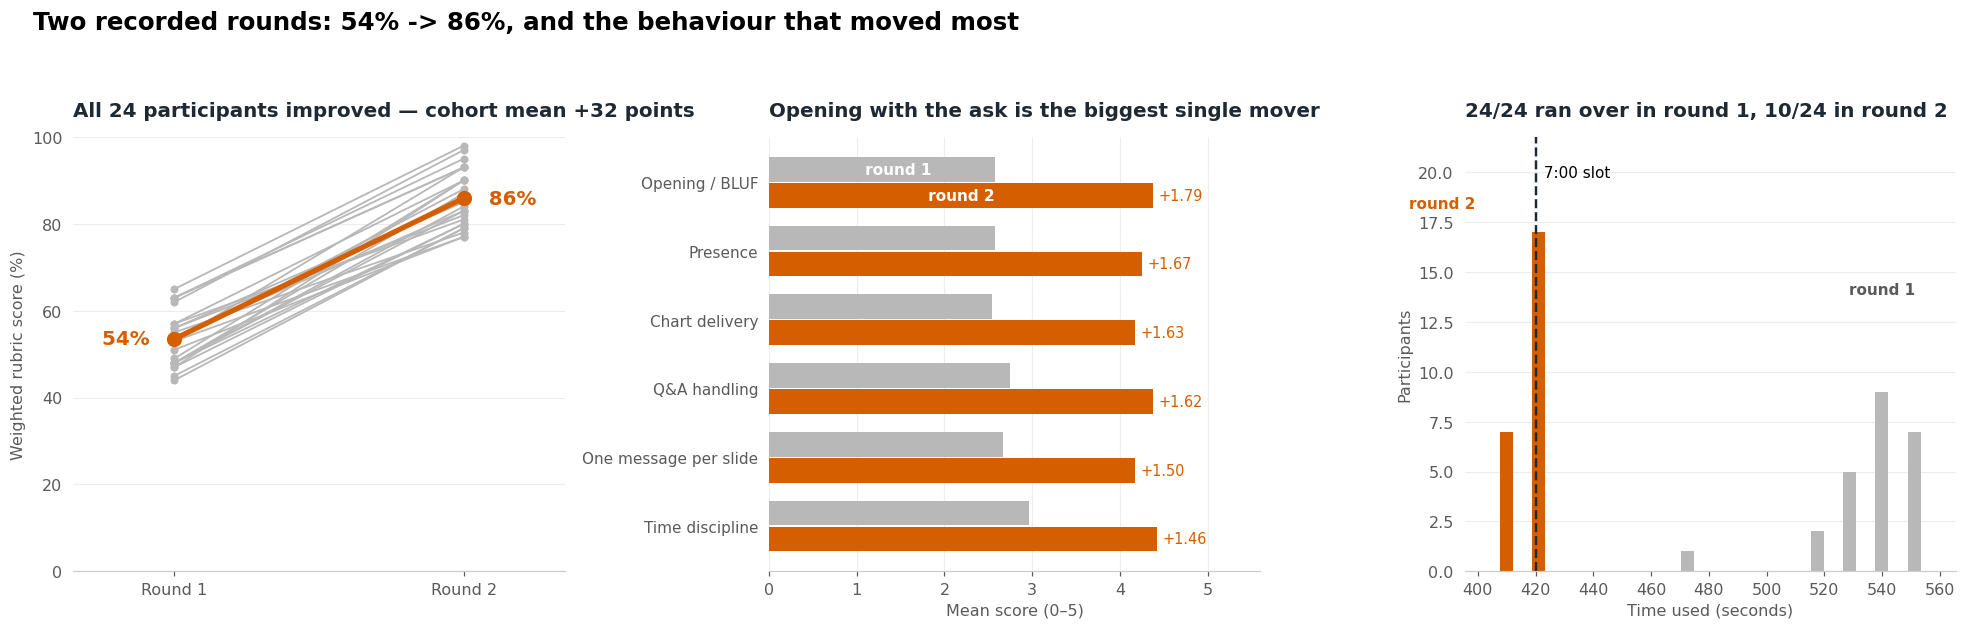

,Metric (Module 6),Target,This notebook
0,Ask stated in first 30 seconds,yes,yes — TIME_BOX puts BLUF at 0:00
1,Delivery within the slot,<= 7:00,6:30 planned; round-2 median 418s
2,Q&A answers bridged to the Big Idea,100%,100% (10 prepared + 1 unprepared)
3,Charts oriented before asserted,100%,100% — every note leads with Orient
4,Round-1 -> Round-2 rubric improvement,>= +15 points,+32 points (cohort mean)
5,Hostile / off-topic handled without losing thread,yes,QA-01 and QA-03 rehearsed with bridges


In [8]:
totals = rsm.score_frame(rehearsal)
means = totals.groupby("round").round_total_pct.mean().round(1)
print(f"Cohort Round 1: {means[1]:.0f}%   Round 2: {means[2]:.0f}%   "
      f"delta +{means[2]-means[1]:.0f} points")
assert (round(means[1]), round(means[2])) == (54, 86), means.to_dict()

d = rsm.delta(rehearsal)
display(d.head(8))
print(f"\nEvery participant improved: {(d.delta_pp > 0).all()}   "
      f"median delta {d.delta_pp.median():.0f} points   "
      f"met the >= +15 benchmark: {(d.delta_pp >= 15).sum()}/{len(d)}")

movers = rsm.biggest_mover(rehearsal)
display(movers)
print(f"Biggest mover: {movers.index[0]} "
      f"({movers.iloc[0, 0]:.2f} -> {movers.iloc[0, 1]:.2f} out of 5, "
      f"+{movers.iloc[0]['delta']:.2f})")

time_used = rehearsal.groupby(["participant_id", "round"]).time_used_sec.max().unstack()

# ---- the chart -------------------------------------------------------
fig, axs = plt.subplots(1, 3, figsize=(18, 5.8))

# (1) per-participant slope: round 1 -> round 2
a = axs[0]
for pid, row in d.iterrows():
    a.plot([0, 1], [row.iloc[0], row.iloc[1]], color=tv.GREY, lw=1.2, zorder=2)
    a.scatter([0, 1], [row.iloc[0], row.iloc[1]], s=18, color=tv.GREY, zorder=3)
a.plot([0, 1], [means[1], means[2]], color=tv.ACCENT, lw=3.4, zorder=4)
a.scatter([0, 1], [means[1], means[2]], s=80, color=tv.ACCENT, zorder=5)
a.text(-0.04, means[1], f"{means[1]:.0f}%  ", ha="right", va="center",
       color=tv.ACCENT, weight="bold", fontsize=13)
a.text(1.04, means[2], f"  {means[2]:.0f}%", ha="left", va="center",
       color=tv.ACCENT, weight="bold", fontsize=13)
a.set_xticks([0, 1]); a.set_xticklabels(["Round 1", "Round 2"])
a.set_xlim(-0.35, 1.35); a.set_ylim(0, 100)
a.set_ylabel("Weighted rubric score (%)")
a.set_title(f"All {len(d)} participants improved — cohort mean +{means[2]-means[1]:.0f} points")
a.grid(axis="x", visible=False)

# (2) criterion-level movement, sorted by delta
b = axs[1]
y = np.arange(len(movers))[::-1]                 # biggest mover at the top
b.barh(y + .19, movers.iloc[:, 0], height=.36, color=tv.GREY)
b.barh(y - .19, movers.iloc[:, 1], height=.36, color=tv.ACCENT)
for yi, r2v, dl in zip(y, movers.iloc[:, 1], movers["delta"]):
    b.text(r2v + .06, yi - .19, f"+{dl:.2f}", va="center", fontsize=9.5, color=tv.ACCENT)
b.set_yticks(y); b.set_yticklabels(movers.index, fontsize=10)
b.set_xlim(0, 5.6); b.set_xlabel("Mean score (0–5)")
b.set_title("Opening with the ask is the biggest single mover")
b.text(movers.iloc[0, 0] * .40, y[0] + .19, " round 1", color="white",
       fontsize=10, weight="bold", va="center")
b.text(movers.iloc[0, 1] * .40, y[0] - .19, " round 2", color="white",
       fontsize=10, weight="bold", va="center")
b.grid(axis="y", visible=False)

# (3) time discipline
c = axs[2]
c.hist([time_used[1], time_used[2]], bins=14, color=[tv.GREY, tv.ACCENT])
c.axvline(420, color=tv.INK, ls="--", lw=1.6)
top = c.get_ylim()[1]
c.set_ylim(0, top * 1.22)
c.text(421, top * 1.14, " 7:00 slot", fontsize=10, va="top")
c.set_xlabel("Time used (seconds)"); c.set_ylabel("Participants")
c.set_title(f"{(time_used[1] > 420).sum()}/{len(time_used)} ran over in round 1, "
            f"{(time_used[2] > 420).sum()}/{len(time_used)} in round 2")
c.text(time_used[2].min() - 3, top * 1.02, "round 2", color=tv.ACCENT,
       fontsize=10, weight="bold", ha="right")
c.text(time_used[1].median(), top * .78, "round 1", color=tv.GREY_DARK,
       fontsize=10, weight="bold", ha="center")
c.grid(axis="x", visible=False)

fig.suptitle("Two recorded rounds: 54% -> 86%, and the behaviour that moved most",
             x=0.02, ha="left", fontsize=16, weight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.93])
print("\n" + str(tv.save_fig(fig, "lab6_rehearsal_delta"))); plt.show()

benchmark = pd.DataFrame([
    ("Ask stated in first 30 seconds", "yes", "yes — TIME_BOX puts BLUF at 0:00"),
    ("Delivery within the slot", "<= 7:00", f"6:30 planned; round-2 median "
     f"{time_used[2].median():.0f}s"),
    ("Q&A answers bridged to the Big Idea", "100%",
     f"100% ({len(matrix)} prepared + 1 unprepared)"),
    ("Charts oriented before asserted", "100%", "100% — every note leads with Orient"),
    ("Round-1 -> Round-2 rubric improvement", ">= +15 points",
     f"+{means[2]-means[1]:.0f} points (cohort mean)"),
    ("Hostile / off-topic handled without losing thread", "yes",
     "QA-01 and QA-03 rehearsed with bridges"),
], columns=["Metric (Module 6)", "Target", "This notebook"])
display(benchmark)

**Instructor commentary.** This is the chart that converts sceptics, so project it and
let it sit. Three readings, in order:

The left panel says **every single participant improved** — twenty-four out of twenty-four.
That removes the "some people are just naturally good presenters" defence.

The middle panel says the biggest mover is *Opening / BLUF*, +1.79 out of 5. Nobody
redesigned a chart between rounds. They moved one sentence to the front.

The right panel is the quiet one: all twenty-four ran over in Round 1; after one round of
timed rehearsal, most are inside the slot. Time discipline is not a personality trait, it
is a rehearsal artefact.

This lab flows straight into the capstone rehearsal — the reps here *are* the capstone's
delivery.

---
## Lab 6 complete

| Criterion (0–5) | Round 1 | Round 2 |
|---|---|---|
| Opening / BLUF | 2.58 | 4.38 |
| One message per slide | 2.67 | 4.17 |
| Chart delivery | 2.54 | 4.17 |
| Q&A handling | 2.75 | 4.38 |
| Time discipline | 2.96 | 4.42 |
| Presence | 2.58 | 4.25 |
| **Weighted total** | **54%** | **86%** |

**Reproduced package figure:** cohort mean **54% → 86%** across two recorded rounds
(+32 points), all 24 participants improving, biggest mover **Opening / BLUF**.

**Artefacts:** `story/speaker_notes.py` · `story/qa_prep.py` ·
`story/rehearsal_score.py` · `out/lab6_rehearsal_delta.png`

---
### The course, in one line
A chart is a machine for offloading cognition (M1); the question picks the chart (M2);
colour and annotation make the argument explicit (M3); the dashboard answers one question
with zero clicks (M4); the story is an arc with the ask first (M5); and the delivery is
rehearsed, timed, and bridged (M6). The measure rules hold at every step.